In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import h5py
import scipy

from gabi_decomp import *
from alfven_decomp import *

In [35]:
filename = '/home/stsoukalas/mode_profiles.hdf5'

f = h5py.File(filename, 'r')
x = f['coords/x']
y = f['coords/y']
z = f['coords/z']
r_vals = f['coords/r_vals']
t = f['coords/t']

Br = f['modes/Br']
Bp = f['modes/Bp']
Bz = f['modes/Bz']

Br_rec_test = f['reconstructions/Br']
Bp_rec_test = f['reconstructions/Bp']
Bz_rec_test = f['reconstructions/Bz']

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/home/stsoukalas/mode_profiles.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

/tmp/ipykernel_38912/3989419026.py:11: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(X_rec, Y_rec, Bz_rec_test[100][3][:,0].T, cmap='RdBu_r')


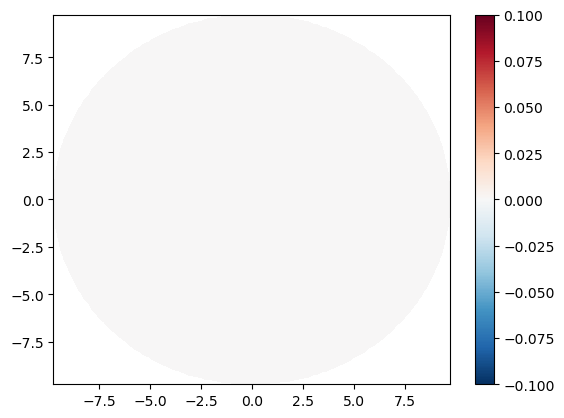

In [48]:
Br_rec_test = f['reconstructions/Br']
Bp_rec_test = f['reconstructions/Bp']
Bz_rec_test = f['reconstructions/Bz']

X, Y = np.meshgrid(x, y, indexing='xy')
phi = gen_phi(256)

X_rec, Y_rec = get_rec_cartesian_domain(r_vals, phi)
Br_rec, Bp_rec, Bz_rec = reconstruct_modes(Br[0], Bp[0], Bz[0], phi, 1)
R, PHI = np.meshgrid(r_vals, phi, indexing='xy')
plt.pcolormesh(X_rec, Y_rec, Bz_rec_test[100][3][:,0].T, cmap='RdBu_r')
plt.colorbar()